#### In this notebook we use the cleaned DHS KR child files to look at long term trends in child malnutrition across East Africa.We focus on height for age (HAZ), which is a standard way to measure stunting. We combine all the KR files we cleaned earlier, keep the survey year and HAZ, and build one big table of children across Ethiopia, Kenya, Tanzania, and Uganda.Then we calculate the mean HAZ and the percent of children who are stunted (HAZ below -2) for each survey year and each country. Finally, we make simple line plots to see how stunting has changed over time in the four countries.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


In [5]:
kr_files = [
    "Ethiopia_KR_1992_clean.csv",
    "Ethiopia_KR_1997_clean.csv",
    "Ethiopia_KR_2003_clean.csv",
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_89_clean.csv",
    "Kenya_KR_93_clean.csv",
    "Kenya_KR_98_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_92_clean.csv",
    "Tanzania_KR_96_clean.csv",
    "Tanzania_KR_99_clean.csv",
    "Tanzania_KR_2004_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_88_clean.csv",
    "Uganda_KR_95_clean.csv",
    "Uganda_KR_2001_clean.csv",
    "Uganda_KR_2006_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]

#### Here we loop over all the cleaned KR files.

For each file we:
- read the csv
- check that it has height for age and interview year
- keep only those two columns
- add a simple country label based on the file name
- stack all rows together into one DataFrame called child_data.


In [12]:
child_list = []

for fname in kr_files:
    df = pd.read_csv(fname)
    cols = df.columns
    
    # we only keep files that actually have HAZ and interview year
    if ("height for age SD per WHO" in cols) and ("interview year" in cols):
        # keep only the columns we need
        small = df[["height for age SD per WHO", "interview year"]].copy()
        
        # simple country name from the file name (first part before "_")
        country_name = fname.split("_")[0]
        small["country"] = country_name
        
        # rename so the column names are shorter to type later
        small = small.rename(columns={
            "height for age SD per WHO": "haz",
            "interview year": "survey_year",
        })
        
        child_list.append(small)

# put everything into one table
child_data = pd.concat(child_list, ignore_index=True)

child_data.head()


,haz,survey_year,country
0,-226.0,2003,Ethiopia
1,-379.0,2003,Ethiopia
2,-301.0,2003,Ethiopia
3,-300.0,2003,Ethiopia
4,-83.0,2003,Ethiopia


##### Next we clean up the combined child table a little.

We:
- drop rows where HAZ is missing
- create a stunting flag where haz < -2


In [16]:
# drop missing HAZ
child_data = child_data.dropna(subset=["haz"])

# stunting flag: True if HAZ < -2
child_data["is_stunted"] = child_data["haz"] < -2

child_data[["country", "survey_year", "haz", "is_stunted"]].head()


,country,survey_year,haz,is_stunted
0,Ethiopia,2003,-226.0,True
1,Ethiopia,2003,-379.0,True
2,Ethiopia,2003,-301.0,True
3,Ethiopia,2003,-300.0,True
4,Ethiopia,2003,-83.0,True


#### Next step is to e group b `county` an `survey_yer` and calculate:
- the mean HAZ
- the stunting rate (share of children with HAZ below -2)
- the number of children in each group (just for context)

We also convert the stunting rate into a percentage so it is easier to read.



In [19]:
summary = (
    child_data
    .groupby(["country", "survey_year"])
    .agg(
        mean_haz=("haz", "mean"),
        stunting_rate=("is_stunted", "mean"),
        n_children=("haz", "size"),
    )
    .reset_index()
)

summary["stunting_percent"] = summary["stunting_rate"] * 100

summary.head()


,country,survey_year,mean_haz,stunting_rate,n_children,stunting_percent
0,Ethiopia,2003,681.782824,0.762023,10480,76.202290
1,Ethiopia,2008,1.683302,0.786900,8977,78.689986
2,Ethiopia,2011,-44.234101,0.829107,5126,82.910652
3,Kenya,2008,692.783447,0.732021,2489,73.202089
4,Kenya,2009,510.431523,0.767078,3001,76.707764


In [209]:
# put all countries / years together
children_all_years = pd.concat(child_rows, ignore_index=True)

# drop rows with missing HAZ
children_all_years = children_all_years.dropna(subset=["haz"]).copy()

# stunted if HAZ < -2
children_all_years["is_stunted"] = children_all_years["haz"] < -2

# quick check of what we got
children_all_years[["country", "survey_year"]].drop_duplicates().sort_values(
    ["country", "survey_year"]
)



,country,survey_year
0,Ethiopia,2003
11654,Ethiopia,2008
22295,Ethiopia,2011
28116,Kenya,2008
28048,Kenya,2009
34127,Kenya,2014
55091,Kenya,2022
74940,Tanzania,2009
74621,Tanzania,2010
82644,Tanzania,2015


In [211]:
stunting_trend = (
    children_all_years
    .groupby(["country", "survey_year"])["is_stunted"]
    .agg(stunted_rate="mean", n_children="count")
    .reset_index()
    .sort_values(["country", "survey_year"])
)

stunting_trend.head()


,country,survey_year,stunted_rate,n_children
0,Ethiopia,2003,0.762023,10480
1,Ethiopia,2008,0.786900,8977
2,Ethiopia,2011,0.829107,5126
3,Kenya,2008,0.732021,2489
4,Kenya,2009,0.767078,3001


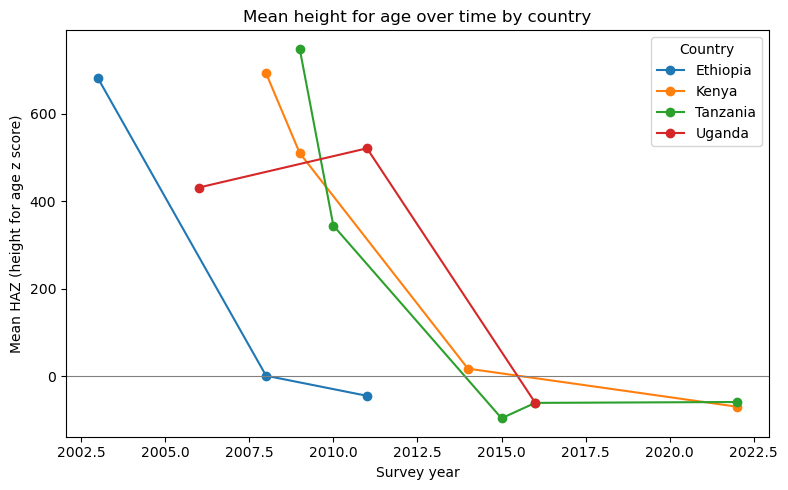

In [21]:
plt.figure(figsize=(8, 5))

countries = summary["country"].unique()

for country in countries:
    sub = summary[summary["country"] == country]
    plt.plot(sub["survey_year"], sub["mean_haz"], marker="o", label=country)

plt.axhline(0, color="gray", linewidth=0.8)  # zero line for reference

plt.xlabel("Survey year")
plt.ylabel("Mean HAZ (height for age z score)")
plt.title("Mean height for age over time by country")
plt.legend(title="Country")
plt.tight_layout()
plt.show()



#### Next we look at the percent of children who are stunted over time.This is easier to interpret because it shows something like “X percent of children are stunted in this country and year” instead of raw z scores.


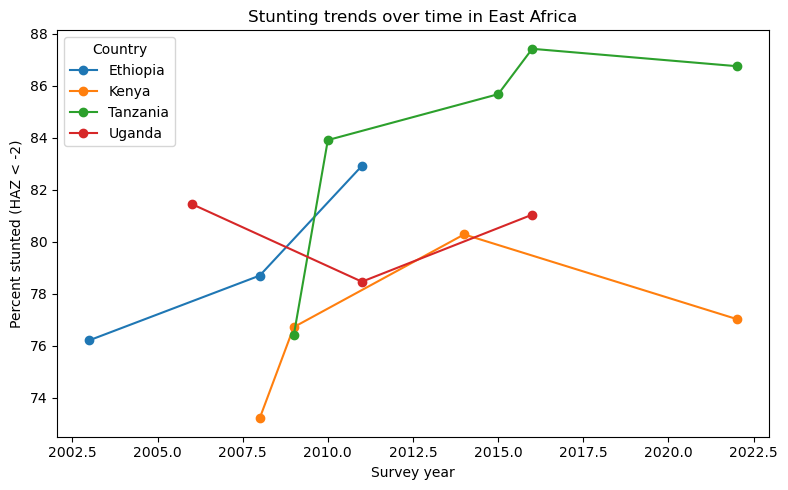

In [25]:
plt.figure(figsize=(8, 5))

for country in countries:
    sub = summary[summary["country"] == country]
    plt.plot(sub["survey_year"], sub["stunting_percent"], marker="o", label=country)

plt.xlabel("Survey year")
plt.ylabel("Percent stunted (HAZ < -2)")
plt.title("Stunting trends over time in East Africa")
plt.legend(title="Country")
plt.tight_layout()
plt.show()


##### Here we make a bar chart.For each country we plot the percent of children who are stunted in each survey year. This makes it easier to see which years are higher or lower and how the pattern differs across Ethiopia, Kenya, Tanzania, and Uganda.


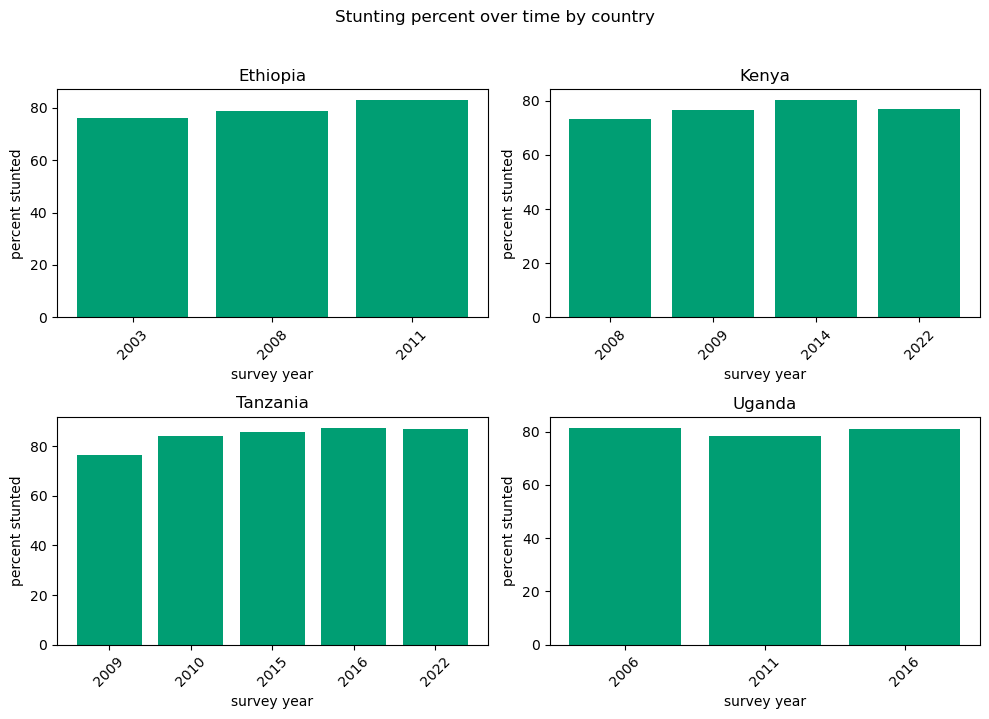

In [36]:
# bar chart of stunting over time, one small plot per country

countries = summary["country"].unique()

plt.figure(figsize=(10, 7))

for i, c in enumerate(countries):
    plt.subplot(2, 2, i + 1)
    
    # keep rows for this country and sort by year
    sub = summary[summary["country"] == c].copy()
    sub = sub.sort_values("survey_year")
    
    x_vals = sub["survey_year"].astype(str)
    y_vals = sub["stunting_percent"]
    
    # bright colorblind safe color

    plt.bar(x_vals, y_vals, color="#009E73")
    
    plt.title(c)
    plt.xlabel("survey year")
    plt.ylabel("percent stunted")
    plt.xticks(rotation=45)

plt.suptitle("Stunting percent over time by country", y=1.02)
plt.tight_layout()
plt.show()



##### In this section we switch and look at how stunting varies across wealth groups. This helps us see whether children in poorer households are consistently more affected by malnutrition.

In [42]:
sns.set_theme(style="whitegrid")

# most recent KR file for each country
recent_files = {
    "Ethiopia": "Ethiopia_KR_2011_clean.csv",
    "Kenya": "Kenya_KR_2022_clean.csv",
    "Tanzania": "Tanzania_KR_2022_clean.csv",
    "Uganda": "Uganda_KR_2016_clean.csv",
}

# we will collect one small table per country
rows = []

for country, fname in recent_files.items():
    df = pd.read_csv(fname)
    cols = df.columns.tolist()

    # check that we have the columns we need
    if "height for age SD per WHO" not in cols:
        continue
    if "wealth_quartile" not in cols:
        continue

    # drop rows with missing values
    mini = df[["height for age SD per WHO", "wealth_quartile"]].dropna()

    # flag stunted children (HAZ < -2)
    mini["is_stunted"] = mini["height for age SD per WHO"] < -2

    # percent stunted by wealth quartile
    grouped = mini.groupby("wealth_quartile")["is_stunted"].mean() * 100

    for wq, pct in grouped.items():
        rows.append({
            "country": country,
            "wealth_quartile": wq,
            "stunting_percent": pct
        })

stunting_wealth_recent = pd.DataFrame(rows)
stunting_wealth_recent.head()


,country,wealth_quartile,stunting_percent
0,Ethiopia,1,80.345040
1,Ethiopia,2,85.221675
2,Ethiopia,3,87.317073
3,Ethiopia,4,84.929757
4,Ethiopia,5,80.238971


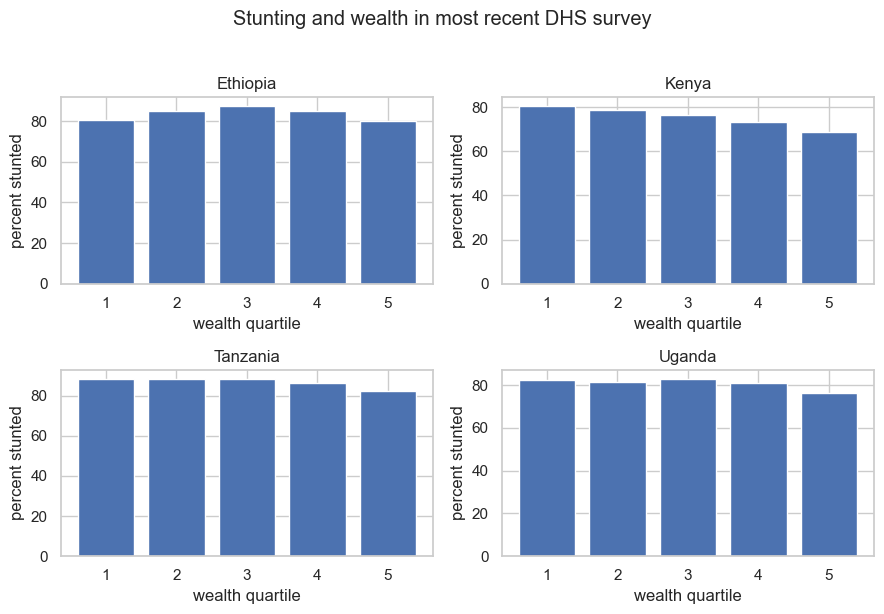

In [44]:
# order for the x-axis so it is not scrambled
quartile_order = sorted(stunting_wealth_recent["wealth_quartile"].unique())

plt.figure(figsize=(9, 6))

# one subplot per country (2x2 grid)
countries = ["Ethiopia", "Kenya", "Tanzania", "Uganda"]

for i in range(len(countries)):
    c = countries[i]
    plt.subplot(2, 2, i + 1)

    sub = stunting_wealth_recent[stunting_wealth_recent["country"] == c]

    plt.bar(sub["wealth_quartile"], sub["stunting_percent"])
    plt.xlabel("wealth quartile")
    plt.ylabel("percent stunted")
    plt.title(c)

plt.suptitle("Stunting and wealth in most recent DHS survey", y=1.02)
plt.tight_layout()
plt.show()


#### We flagged children as stunted when their height-for-age z score (HAZ) was below -2. To simplify long-term analysis, survey years were grouped into decades.  For each country and decade, we calculated the number of children observed and the average stunting rate. The stunting rate was converted into a percentage to make results easier to interpret The next step is creating a heatmap, showing how stunting has shifted across countries over time.  This visualization highlights both regional differences and long-term progress in reducing child malnutrition.  


In [54]:
children_list = []

for fname in kr_files:
    df = pd.read_csv(fname)
    
    # get country name from file name, for example "Kenya_KR_2014_clean.csv" -> "Kenya"
    country_name = fname.split("_")[0]
    
    # use the interview year column
    if "interview year" in df.columns:
        year_col = "interview year"
    elif "interview_year" in df.columns:
        year_col = "interview_year"
    else:
        continue
    
    # find the height for age Z score column
    haz_col = None
    if "height for age SD per WHO" in df.columns:
        haz_col = "height for age SD per WHO"
    elif "z_height_for_age" in df.columns:
        haz_col = "z_height_for_age"
    elif "haz_height_for_age_z" in df.columns:
        haz_col = "haz_height_for_age_z"
    
    if haz_col is None:
        continue
    
    # keep only what we need from this file
    tmp = df[[year_col, haz_col]].copy()
    tmp = tmp.rename(columns={year_col: "survey_year", haz_col: "haz"})
    tmp["country"] = country_name
    
    children_list.append(tmp)

# stack everything into one data frame
children_all = pd.concat(children_list, ignore_index=True)

children_all.head()


,survey_year,haz,country
0,2003,-226.0,Ethiopia
1,2003,-379.0,Ethiopia
2,2003,-301.0,Ethiopia
3,2003,-300.0,Ethiopia
4,2003,-83.0,Ethiopia


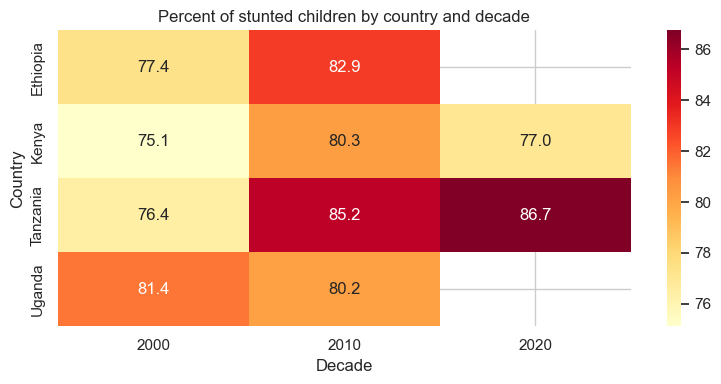

In [68]:
# stunting flag
children_all["is_stunted"] = children_all["haz"] < -2

# make a simple decade variable, for example 1992 -> 1990
def make_decade(y):
    return int(y // 10) * 10

children_all = children_all.dropna(subset=["survey_year", "haz"]).copy()
children_all["decade"] = children_all["survey_year"].apply(make_decade)

# group by country and decade
stunting_decade = (
    children_all
    .groupby(["country", "decade"])
    .agg(
        n_children=("haz", "size"),
        stunting_rate=("is_stunted", "mean"),
    )
    .reset_index()
)

# convert to percent
stunting_decade["stunting_percent"] = stunting_decade["stunting_rate"] * 100

# reshape for heatmap
heat_table = stunting_decade.pivot(
    index="country",
    columns="decade",
    values="stunting_percent"
)

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_table,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Percent of stunted children by country and decade")
plt.xlabel("Decade")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

##### In this section we look at how stunting is related to basic economic conditions using the DHS wealth index. We group children by wealth quartile and calculate the share of stunted children in each group. We keep only surveys that have both height for age z scores and wealth information. The goal is to see whether the stunting burden is concentrated among poorer children and whether that pattern looks similar across the four East African countries.

In [73]:
# we keep only rows that have haz and wealth info
sub = children_all.dropna(subset=["haz", "wealth_quartile"]).copy()

# make sure stunting flag exists (in case we did not run it yet)
sub["is_stunted"] = sub["haz"] < -2

# group by country and wealth quartile and get mean stunting rate
stunting_wealth = (
    sub.groupby(["country", "wealth_quartile"])["is_stunted"]
      .mean()
      .reset_index()
)

# turn the rate into percent to make it easier to talk about
stunting_wealth["stunted_percent"] = stunting_wealth["is_stunted"] * 100

stunting_wealth.head()

KeyError: ['wealth_quartile']